In [ ]:
#Importing Libraries
# Core Python Libraries
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Scikit-learn Utilities
# -----------------------------
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# -----------------------------
# AutoML
# -----------------------------
from autogluon.tabular import TabularPredictor

# -----------------------------
# Hyperparameter Optimization
# -----------------------------
import optuna

In [2]:
#Dataset Loading and Cleaning
df = pd.read_csv(
    "F:/recipe+reviews+and+user+feedback+dataset/Recipe Reviews and User Feedback Dataset.csv"
)

# Drop irrelevant identifier columns
df = df.drop(columns=[
    'Unnamed: 0',
    'comment_id',
    'user_id',
    'user_name'
])

# Remove missing text or star values
df = df.dropna(subset=['text', 'stars'])

df.head()

,recipe_number,recipe_code,recipe_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,1,14299,Creamy White Chili,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,14299,Creamy White Chili,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,1,14299,Creamy White Chili,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,1,14299,Creamy White Chili,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,1,14299,Creamy White Chili,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...


In [3]:
#Creating Sentiment Labels
def star_to_sentiment(star):
    star = int(star)
    if star <= 2:
        return "negative"
    elif star == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['stars'].apply(star_to_sentiment)

df[['stars', 'sentiment']].value_counts()

stars  sentiment
5      positive     13827
0      negative      1696
4      positive      1655
3      neutral        490
1      negative       280
2      negative       232
Name: count, dtype: int64

In [4]:
#Feature Selection
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = ['recipe_name']
text_feature = 'text'
target = 'sentiment'

In [5]:
#Train–Test Split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[target]
)

X_train = train_df.drop(columns=target)
y_train = train_df[target]

X_test = test_df.drop(columns=target)
y_test = test_df[target]

In [6]:
#AutoGluon – Automatic Model Selection
predictor = TabularPredictor(
    label=target,
    problem_type='multiclass',
    eval_metric='accuracy'
).fit(
    train_df,
    presets='medium_quality',
    time_limit=300
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260414_212910"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.87 GB / 15.65 GB (18.4%)
Disk Space Avail:   265.61 GB / 464.74 GB (57.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "C:\Data\GitHub\Inria SKlearn\scikit-learn-mooc-main\Class\AutogluonModels\ag-20260414_212910"
Train Data Rows:    14544
Train Data Columns: 11
Label Column:       sentiment
Problem Type:       multiclass
Preprocessing data ...
Train Data Class Count: 3
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineF

In [7]:
predictor.leaderboard(test_df, silent=False)

                 model  score_test  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0             LightGBM    1.000000   1.000000    accuracy        0.173046       0.045070    4.532843                 0.173046                0.045070           4.532843            1       True          3
1           LightGBMXT    1.000000   1.000000    accuracy        0.188056       0.047750    9.714728                 0.188056                0.047750           9.714728            1       True          2
2              XGBoost    1.000000   1.000000    accuracy        0.431279       0.077624    7.918442                 0.431279                0.077624           7.918442            1       True          8
3      NeuralNetFastAI    0.998900   1.000000    accuracy        0.143379       0.025471   20.681450                 0.143379                0.025471          20.681450            1   

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,1.000000,1.000000,accuracy,0.173046,0.045070,4.532843,0.173046,0.045070,4.532843,1,True,3
1,LightGBMXT,1.000000,1.000000,accuracy,0.188056,0.047750,9.714728,0.188056,0.047750,9.714728,1,True,2
2,XGBoost,1.000000,1.000000,accuracy,0.431279,0.077624,7.918442,0.431279,0.077624,7.918442,1,True,8
3,NeuralNetFastAI,0.998900,1.000000,accuracy,0.143379,0.025471,20.681450,0.143379,0.025471,20.681450,1,True,1
4,WeightedEnsemble_L2,0.998900,1.000000,accuracy,0.163592,0.025471,20.968500,0.020213,0.000000,0.287050,2,True,10
5,NeuralNetTorch,0.987349,0.990378,accuracy,0.097728,0.048218,180.409878,0.097728,0.048218,180.409878,1,True,9
6,RandomForestGini,0.970847,0.972509,accuracy,0.366764,0.142501,11.178976,0.366764,0.142501,11.178976,1,True,4
7,ExtraTreesGini,0.965897,0.967698,accuracy,0.434966,0.182598,12.822091,0.434966,0.182598,12.822091,1,True,6
8,ExtraTreesEntr,0.954620,0.958076,accuracy,0.444995,0.141183,12.794813,0.444995,0.141183,12.794813,1,True,7
9,RandomForestEntr,0.937019,0.940206,accuracy,0.396291,0.171352,9.726741,0.396291,0.171352,9.726741,1,True,5


In [8]:
#AutoGluon Model Evaluation
y_pred_ag = predictor.predict(test_df)

print("AutoGluon Sentiment Accuracy:")
print(accuracy_score(y_test, y_pred_ag))

print(classification_report(y_test, y_pred_ag))


AutoGluon Sentiment Accuracy:
0.9988998899889989
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       442
     neutral       0.99      0.97      0.98        98
    positive       1.00      1.00      1.00      3096

    accuracy                           1.00      3636
   macro avg       0.99      0.99      0.99      3636
weighted avg       1.00      1.00      1.00      3636



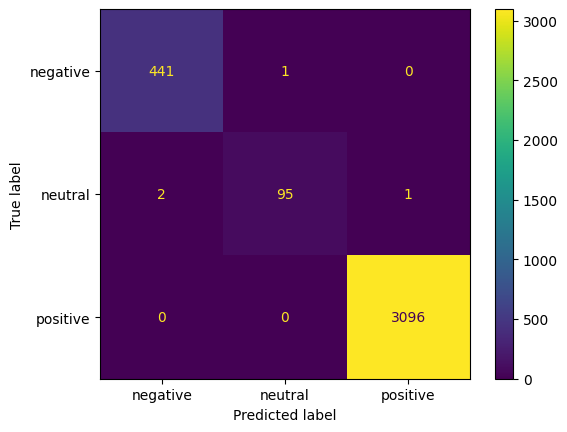

In [9]:

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ag)
plt.show()


In [10]:
#Preprocessing Pipeline for Optuna
def make_preprocessor(max_features):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('text', TfidfVectorizer(
                stop_words='english',
                max_features=max_features
            ), text_feature)
        ]
    )


In [11]:
#Optuna Hyperparameter Optimization
def objective(trial):
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    max_features = trial.suggest_int("max_features", 3000, 7000, step=1000)

    pipeline = Pipeline([
        ('preprocessor', make_preprocessor(max_features)),
        ('classifier', LogisticRegression(
            C=C,
            max_iter=1000,
            n_jobs=-1
        ))
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    return scores.mean()


In [13]:
%%time
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

study.best_params


[I 2026-04-14 18:40:48,614] A new study created in memory with name: no-name-913616a0-17f4-426e-ba06-99276418f062
[I 2026-04-14 18:40:57,020] Trial 0 finished with value: 0.9999312478514953 and parameters: {'C': 0.2696405154158308, 'max_features': 3000}. Best is trial 0 with value: 0.9999312478514953.
[I 2026-04-14 18:41:05,309] Trial 1 finished with value: 0.972909809380649 and parameters: {'C': 0.00546893328332547, 'max_features': 7000}. Best is trial 0 with value: 0.9999312478514953.
[I 2026-04-14 18:41:13,723] Trial 2 finished with value: 0.9989686232027626 and parameters: {'C': 0.04218418234456408, 'max_features': 4000}. Best is trial 0 with value: 0.9999312478514953.
[I 2026-04-14 18:41:22,411] Trial 3 finished with value: 0.9999312478514953 and parameters: {'C': 0.20009105938909236, 'max_features': 7000}. Best is trial 0 with value: 0.9999312478514953.
[I 2026-04-14 18:41:30,502] Trial 4 finished with value: 0.972909809380649 and parameters: {'C': 0.004730231394434579, 'max_feat

CPU times: total: 1min 1s
Wall time: 3min 30s


{'C': 8.758734360086095, 'max_features': 3000}

In [17]:
#Final Optimized Sentiment Model
final_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(study.best_params['max_features'])),
    ('classifier', LogisticRegression(
        C=study.best_params['C'],
        max_iter=1000,
        n_jobs=-1
    ))
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
#Final Evaluation & Interpretation
optuna_preds = final_pipeline.predict(X_test)

print("Optimized Logistic Regression Accuracy:")
print(accuracy_score(y_test, optuna_preds))

print(classification_report(y_test, optuna_preds))


Optimized Logistic Regression Accuracy:
1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       442
     neutral       1.00      1.00      1.00        98
    positive       1.00      1.00      1.00      3096

    accuracy                           1.00      3636
   macro avg       1.00      1.00      1.00      3636
weighted avg       1.00      1.00      1.00      3636



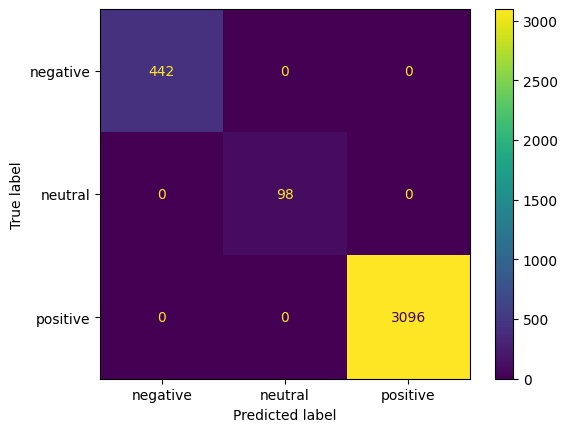

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, optuna_preds)
plt.show()